# Student Performance Analysis using different ML algorithms

In [57]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Data Preprocessing

The dataset was loaded using Pandas and inspected for missing values.

Categorical features were converted into numerical format using OneHotEncoder.

The target variable was selected as G3 (final grade).

The data was then split into training and validation sets using train_test_split.

In [58]:
df = pd.read_csv("student_data.csv")

In [59]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Exploratory Data Analysis

The dataset contains demographic, family, lifestyle, and academic information about students.

Several variables were expected to influence academic performance, including:

- Study time
- Previous failures
- Absences
- Parental education
- Family relationships
- Alcohol consumption

Special attention was given to the impact of previous grades (G1 and G2) on final grade prediction.

### Feature Encoding

Machine learning models cannot directly process text-based categorical values.

Features such as school, sex, address, family size, parental status, and occupations were encoded using OneHotEncoder.

The encoded features were then combined with the numerical features to create the final feature matrix.

## Using LinearRegression Model

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

In [61]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
enc_obj = encoder.fit_transform(df.select_dtypes(include="object"))
num_df = df.select_dtypes(include="number")
encoded  = pd.concat([enc_obj,num_df],axis=1)

##### Model A

In [62]:
X = encoded.drop("G3",axis = 1)
y =encoded["G3"]
train_X, val_X, train_y, val_y = train_test_split(X,y,random_state=1)
Performance_model = LinearRegression()
Performance_model.fit(train_X,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
Predicitons = Performance_model.predict(val_X)
Predicitons
my_mae_model_A = mean_absolute_error(val_y, Predicitons)
my_mae_model_A

1.4213764082739535

##### Model B

In [64]:
X = encoded.drop(["G3","G2","G1"],axis = 1)
y =encoded["G3"]
train_X, val_X, train_y, val_y = train_test_split(X,y,random_state=1)
Performance_model.fit(train_X,train_y)
Predicitons = Performance_model.predict(val_X)
my_mae_model_B = mean_absolute_error(val_y, Predicitons)
my_mae_model_B

3.5707376870893253

## Using Decision Tree

In [65]:
from sklearn.tree import DecisionTreeRegressor
Performance_tree_model = DecisionTreeRegressor(max_depth=5, random_state=1)
Performance_tree_model.fit(train_X,train_y)
predictions = Performance_tree_model.predict(val_X)
my_mae_DecisionTree = mean_absolute_error(val_y, predictions)
my_mae_DecisionTree

3.0421831261015324

## Using  Random Forest

In [66]:
from sklearn.ensemble import RandomForestRegressor
Performance_forest_model = RandomForestRegressor(n_estimators=100, random_state=1)
Performance_forest_model.fit(train_X,train_y)
predictions = Performance_forest_model.predict(val_X)
my_mae_RandomForest = mean_absolute_error(val_y, predictions)
my_mae_RandomForest

2.5646464646464646

## Graphs

In [77]:
models = ["LinearRegression Model A","LinearRegression Model B","Decision Tree", "Random Forest"]
mae_values = [my_mae_model_A,my_mae_model_B,my_mae_DecisionTree,my_mae_RandomForest]
results_df = pd.DataFrame({"Model":models,"MAE":mae_values})
results_df.sort_values("MAE")

,Model,MAE
0,LinearRegression Model A,1.421376
3,Random Forest,2.564646
2,Decision Tree,3.042183
1,LinearRegression Model B,3.570738


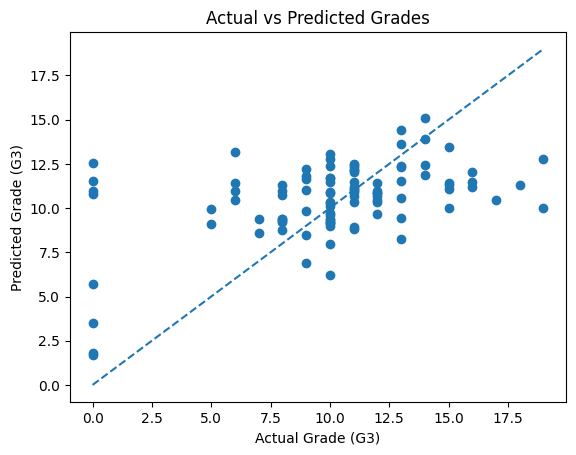

In [ ]:
plt.scatter(val_y, predictions)

plt.plot(
    [val_y.min(), val_y.max()],
    [val_y.min(), val_y.max()],
    linestyle="--"
)

plt.xlabel("Actual Grade (G3)")
plt.ylabel("Predicted Grade (G3)")
plt.title("Actual vs Predicted Grades")
plt.show()

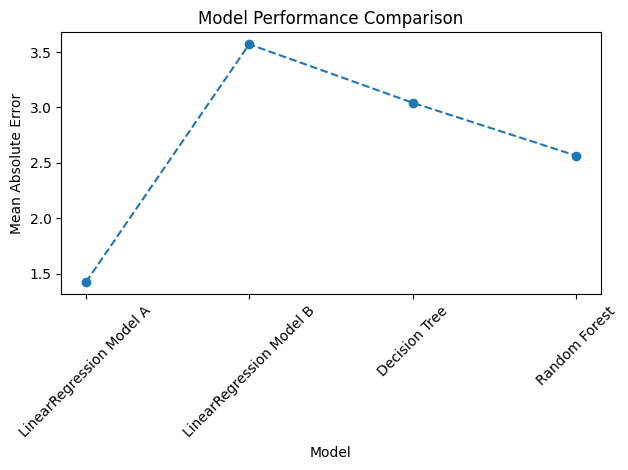

In [78]:
plt.plot(
    results_df["Model"],
    results_df["MAE"],
    marker="o",
    linestyle="--"
)
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("model_comparison.png")

plt.show()

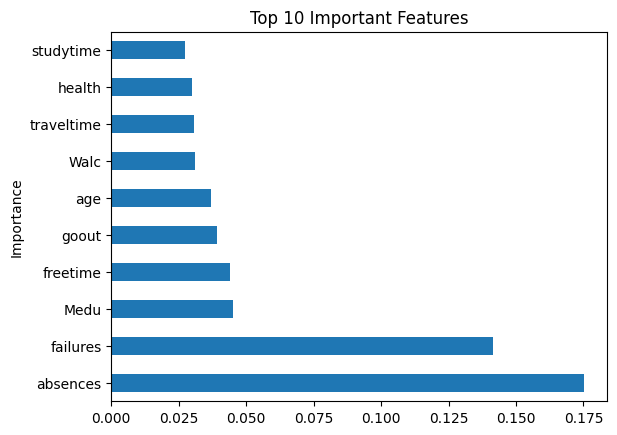

In [79]:
importance = pd.Series(
    Performance_forest_model.feature_importances_,
    index=train_X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.savefig("feature_importance.png")
plt.show()